# Demand Forecasting for High-Priority Grocery Product Families

## Objective

The objective of this notebook is to forecast short-term demand for the most important product families in the grocery retail network.

From the exploratory analysis, the top three product families  `GROCERY I`, `BEVERAGES`, and `PRODUCE` contribute 75.85% of total demand. Because these categories drive most of the sales volume, they are the most important categories for forecasting and replenishment planning.

This notebook uses a professional modelling approach:

1. Build simple baseline forecasting models.
2. Build an ARIMA model as a more advanced statistical model.
3. Compare all models using MAE, RMSE, and MAPE.
4. Select the best-performing model for each product family.
5. Generate a 30-day demand forecast.
6. Export forecast outputs for Power BI and inventory optimization.

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.arima.model import ARIMA

The required libraries were imported. Pandas is used for data analysis, NumPy supports numerical calculations, Matplotlib is used for visualization, OS is used for saving files, and ARIMA is used for time-series forecasting.

### Setting folder paths

In [2]:
folder = r"C:\Users\DEBIDO\Desktop\favorita-grocery-sales-forecasting"

output_folder = folder + r"\outputs"

os.makedirs(output_folder, exist_ok=True)

The project folder path was defined, and an output folder was created to save forecasting results for Power BI and later inventory analysis.

### Loading the final master dataset

In [3]:
master = pd.read_csv(
    folder + r"\final_master_dataset.csv",
    usecols=["date", "family", "unit_sales"]
)

master.head()

,date,unit_sales,family
0,2016-01-01,12.0,GROCERY I
1,2016-01-01,9.0,GROCERY I
2,2016-01-01,3.0,GROCERY I
3,2016-01-01,3.0,GROCERY I
4,2016-01-01,2.0,CLEANING


Only the columns needed for forecasting were loaded. This keeps the notebook faster and avoids unnecessary memory usage.

### Converting date column

In [4]:
master["date"] = pd.to_datetime(master["date"])

master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5922347 entries, 0 to 5922346
Data columns (total 3 columns):
 #   Column      Dtype         
---  ------      -----         
 0   date        datetime64[ns]
 1   unit_sales  float64       
 2   family      object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 135.6+ MB


The date column was converted to datetime format so that the data can be used for time-series forecasting.

### Checking date range

In [5]:
print("Start date:", master["date"].min())
print("End date:", master["date"].max())
print("Number of days:", master["date"].nunique())

Start date: 2016-01-01 00:00:00
End date: 2017-08-15 00:00:00
Number of days: 592


The date range was checked to confirm the historical period available for forecasting.

### Identifying the top 3 product families

In [6]:
family_demand = master.groupby("family")["unit_sales"].sum().sort_values(ascending=False)

top_3_families = family_demand.head(3).index.tolist()

top_3_families

['GROCERY I', 'BEVERAGES', 'PRODUCE']

The top three product families were selected based on total demand. These families are the main focus because they contribute the largest share of sales volume.

### Filtering to the top 3 families

In [7]:
forecast_data = master[master["family"].isin(top_3_families)].copy()

forecast_data.head()

,date,unit_sales,family
0,2016-01-01,12.0,GROCERY I
1,2016-01-01,9.0,GROCERY I
2,2016-01-01,3.0,GROCERY I
3,2016-01-01,3.0,GROCERY I
5,2016-01-01,1.0,GROCERY I


The dataset was filtered to include only the top three product families. This keeps the forecasting scope focused on high-priority categories.

### Creating daily demand by family

In [8]:
daily_family_demand = forecast_data.groupby(
    ["date", "family"]
)["unit_sales"].sum().reset_index()

daily_family_demand.head()

,date,family,unit_sales
0,2016-01-01,BEVERAGES,5104.000
1,2016-01-01,GROCERY I,3247.000
2,2016-01-01,PRODUCE,2384.509
3,2016-01-02,BEVERAGES,60006.000
4,2016-01-02,GROCERY I,59749.726


Sales were aggregated into daily demand by product family. This creates the time-series structure needed for forecasting.

### Creating a complete daily time series

In [9]:
all_dates = pd.date_range(
    start=daily_family_demand["date"].min(),
    end=daily_family_demand["date"].max(),
    freq="D"
)

complete_index = pd.MultiIndex.from_product(
    [all_dates, top_3_families],
    names=["date", "family"]
)

daily_family_demand = daily_family_demand.set_index(
    ["date", "family"]
).reindex(complete_index).reset_index()

daily_family_demand["unit_sales"] = daily_family_demand["unit_sales"].fillna(0)

daily_family_demand.head()

,date,family,unit_sales
0,2016-01-01,GROCERY I,3247.000
1,2016-01-01,BEVERAGES,5104.000
2,2016-01-01,PRODUCE,2384.509
3,2016-01-02,GROCERY I,59749.726
4,2016-01-02,BEVERAGES,60006.000


A complete daily time series was created for each selected product family. Missing demand values were filled with zero to avoid date gaps during forecasting.

### Plotting daily demand trends

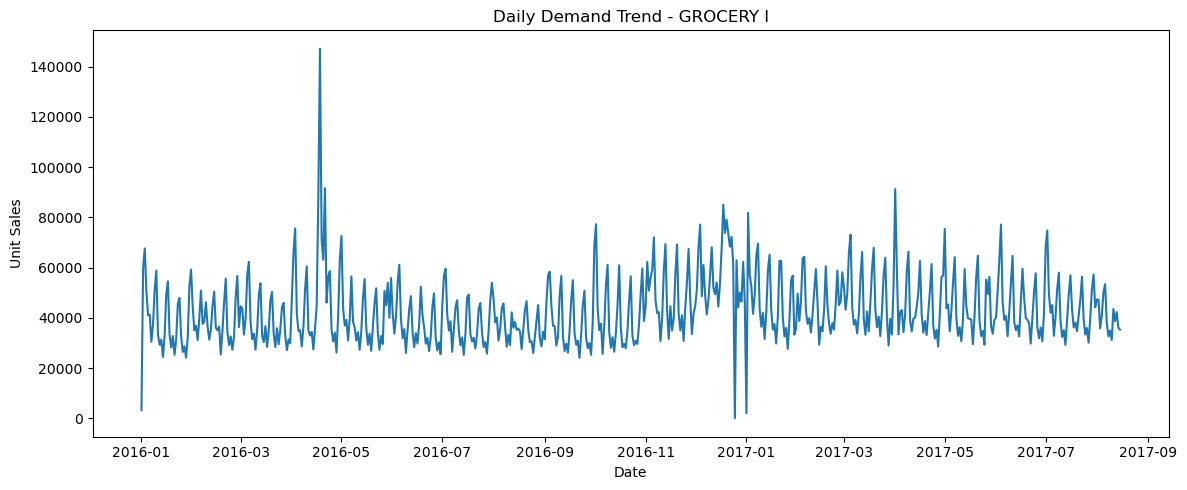

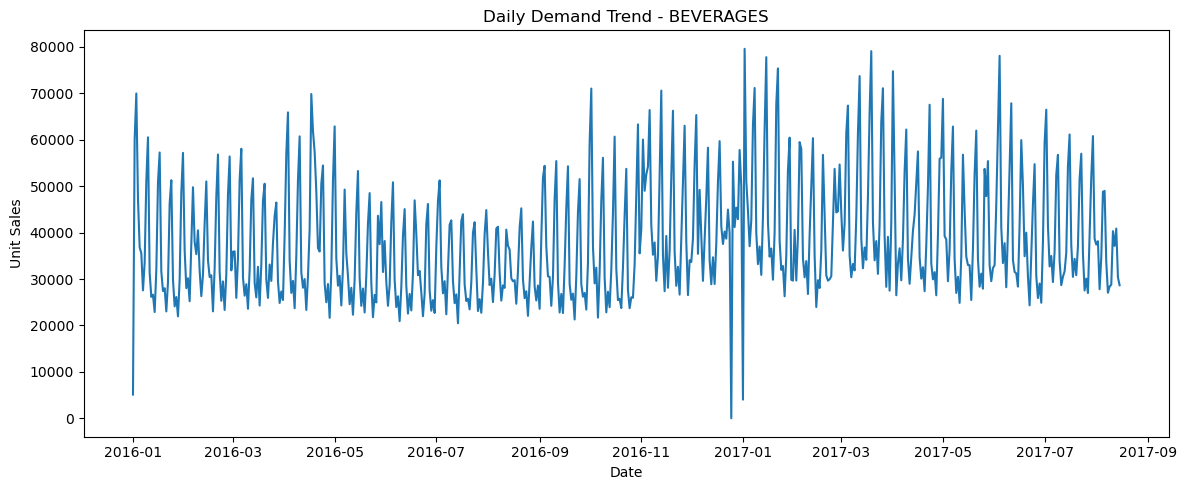

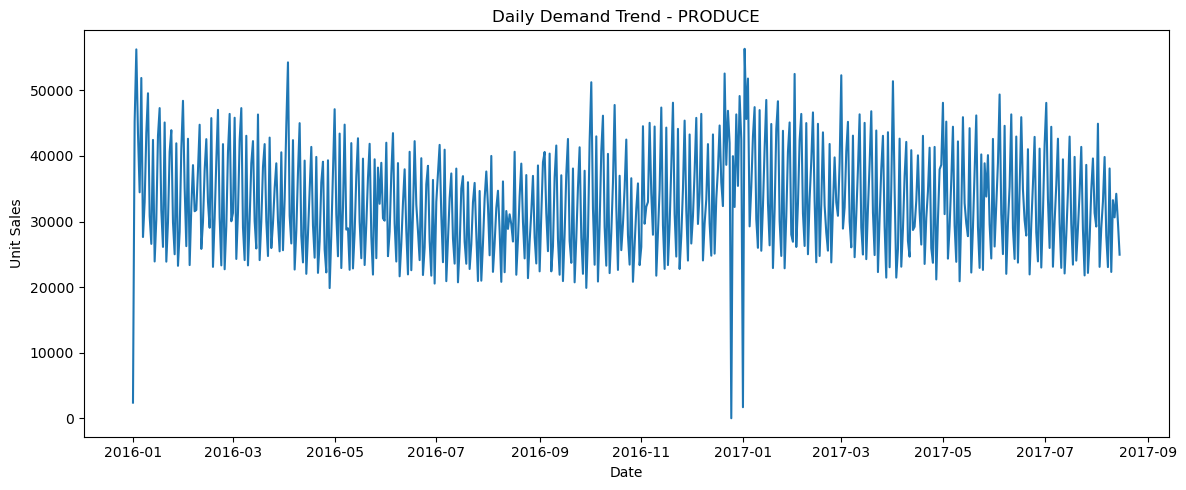

In [11]:
for family in top_3_families:
    family_data = daily_family_demand[
        daily_family_demand["family"] == family
    ]
    
    plt.figure(figsize=(12, 5))
    plt.plot(family_data["date"], family_data["unit_sales"])
    plt.title(f"Daily Demand Trend - {family}")
    plt.xlabel("Date")
    plt.ylabel("Unit Sales")
    plt.tight_layout()
    plt.show()

Daily demand trends were plotted for each top product family to inspect demand movement, spikes, and fluctuations before modelling.

### Creating train - test split

In [12]:
last_date = daily_family_demand["date"].max()
test_start_date = last_date - pd.Timedelta(days=29)

print("Test period starts:", test_start_date)
print("Test period ends:", last_date)

Test period starts: 2017-07-17 00:00:00
Test period ends: 2017-08-15 00:00:00


A time-based train-test split was used. The final 30 days were reserved as the test period so that the models could be evaluated on recent unseen demand.

### Creating accuracy metric function

In [13]:
def calculate_metrics(actual, forecast):
    results = pd.DataFrame({
        "actual": actual,
        "forecast": forecast
    }).dropna()
    
    mae = np.mean(np.abs(results["actual"] - results["forecast"]))
    
    rmse = np.sqrt(
        np.mean((results["actual"] - results["forecast"]) ** 2)
    )
    
    non_zero_actuals = results[results["actual"] != 0]
    
    if len(non_zero_actuals) > 0:
        mape = np.mean(
            np.abs(
                (non_zero_actuals["actual"] - non_zero_actuals["forecast"])
                / non_zero_actuals["actual"]
            )
        ) * 100
    else:
        mape = np.nan
    
    return mae, rmse, mape

A function was created to calculate MAE, RMSE, and MAPE. These metrics help measure how close the forecasted demand is to actual demand.

- MAE shows the average error in unit sales.
- RMSE gives more weight to large errors.
- MAPE shows the average percentage error.

### Building baseline forecasting models

In [14]:
baseline_results = []
baseline_validation = []

for family in top_3_families:
    
    family_data = daily_family_demand[
        daily_family_demand["family"] == family
    ].copy()
    
    family_data = family_data.sort_values("date")
    
    family_data["Naive Last Day"] = family_data["unit_sales"].shift(1)
    
    family_data["7-Day Moving Average"] = (
        family_data["unit_sales"].shift(1).rolling(window=7).mean()
    )
    
    family_data["14-Day Moving Average"] = (
        family_data["unit_sales"].shift(1).rolling(window=14).mean()
    )
    
    family_data["7-Day Seasonal Naive"] = family_data["unit_sales"].shift(7)
    
    test_data = family_data[family_data["date"] >= test_start_date].copy()
    
    baseline_models = [
        "Naive Last Day",
        "7-Day Moving Average",
        "14-Day Moving Average",
        "7-Day Seasonal Naive"
    ]
    
    for model_name in baseline_models:
        
        mae, rmse, mape = calculate_metrics(
            test_data["unit_sales"],
            test_data[model_name]
        )
        
        baseline_results.append({
            "family": family,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
        
        temp_validation = pd.DataFrame({
            "date": test_data["date"],
            "family": family,
            "actual": test_data["unit_sales"],
            "forecast": test_data[model_name],
            "model": model_name
        })
        
        baseline_validation.append(temp_validation)

baseline_results = pd.DataFrame(baseline_results)
baseline_validation = pd.concat(baseline_validation, ignore_index=True)

baseline_results

,family,model,MAE,RMSE,MAPE
0,GROCERY I,Naive Last Day,6883.300000,8146.996271,16.886107
1,GROCERY I,7-Day Moving Average,6003.909524,7190.748360,14.941002
2,GROCERY I,14-Day Moving Average,6107.228571,7341.375540,15.247405
3,GROCERY I,7-Day Seasonal Naive,4994.133333,6428.942925,12.806678
4,BEVERAGES,Naive Last Day,8105.466667,10411.852009,21.839518
5,BEVERAGES,7-Day Moving Average,7519.923810,9048.968535,20.789633
6,BEVERAGES,14-Day Moving Average,7589.559524,9158.306825,21.208672
7,BEVERAGES,7-Day Seasonal Naive,4504.766667,5600.401042,12.564688
8,PRODUCE,Naive Last Day,9275.042867,10689.006110,31.593022
9,PRODUCE,7-Day Moving Average,5454.278643,6454.244788,18.639415


Four baseline forecasting models were created and evaluated. Baseline models are important because they provide simple benchmarks before testing a more advanced model like ARIMA.

### Building ARIMA model

In [15]:
arima_results = []
arima_validation = []

for family in top_3_families:
    
    family_data = daily_family_demand[
        daily_family_demand["family"] == family
    ].copy()
    
    family_data = family_data.sort_values("date")
    family_data = family_data.set_index("date").asfreq("D")
    
    train_data = family_data[family_data.index < test_start_date]
    test_data = family_data[family_data.index >= test_start_date]
    
    model = ARIMA(
        train_data["unit_sales"],
        order=(1, 1, 1)
    )
    
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=len(test_data))
    
    mae, rmse, mape = calculate_metrics(
        test_data["unit_sales"].values,
        forecast.values
    )
    
    arima_results.append({
        "family": family,
        "model": "ARIMA(1,1,1)",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })
    
    temp_validation = pd.DataFrame({
        "date": test_data.index,
        "family": family,
        "actual": test_data["unit_sales"].values,
        "forecast": forecast.values,
        "model": "ARIMA(1,1,1)"
    })
    
    arima_validation.append(temp_validation)

arima_results = pd.DataFrame(arima_results)
arima_validation = pd.concat(arima_validation, ignore_index=True)

arima_results

C:\Users\DEBIDO\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,family,model,MAE,RMSE,MAPE
0,GROCERY I,"ARIMA(1,1,1)",7349.191441,8283.553265,19.140753
1,BEVERAGES,"ARIMA(1,1,1)",9115.708999,10313.162635,26.407880
2,PRODUCE,"ARIMA(1,1,1)",5823.315684,6844.173482,20.891816


An ARIMA(1,1,1) model was trained for each of the top three product families. ARIMA was included as a more advanced statistical forecasting model and compared against the baseline models.

ARIMA was not assumed to be the best model automatically. It was tested against baseline models, and the final model choice will be based on forecast accuracy.

### Combining baseline and ARIMA results

In [16]:
all_model_results = pd.concat(
    [baseline_results, arima_results],
    ignore_index=True
)

all_model_results_rounded = all_model_results.copy()

all_model_results_rounded[["MAE", "RMSE", "MAPE"]] = all_model_results_rounded[
    ["MAE", "RMSE", "MAPE"]
].round(2)

all_model_results_rounded

,family,model,MAE,RMSE,MAPE
0,GROCERY I,Naive Last Day,6883.30,8147.00,16.89
1,GROCERY I,7-Day Moving Average,6003.91,7190.75,14.94
2,GROCERY I,14-Day Moving Average,6107.23,7341.38,15.25
3,GROCERY I,7-Day Seasonal Naive,4994.13,6428.94,12.81
4,BEVERAGES,Naive Last Day,8105.47,10411.85,21.84
5,BEVERAGES,7-Day Moving Average,7519.92,9048.97,20.79
6,BEVERAGES,14-Day Moving Average,7589.56,9158.31,21.21
7,BEVERAGES,7-Day Seasonal Naive,4504.77,5600.40,12.56
8,PRODUCE,Naive Last Day,9275.04,10689.01,31.59
9,PRODUCE,7-Day Moving Average,5454.28,6454.24,18.64


ARIMA(1,1,1) was included as an advanced statistical benchmark. However, it did not outperform the 7-Day Seasonal Naive model for any of the top three product families. This shows the importance of comparing advanced models against simple baselines before selecting a forecasting method.

### Selecting the best model for each family

In [17]:
best_models = all_model_results.loc[
    all_model_results.groupby("family")["RMSE"].idxmin()
].reset_index(drop=True)

best_models[["MAE", "RMSE", "MAPE"]] = best_models[
    ["MAE", "RMSE", "MAPE"]
].round(2)

best_models

,family,model,MAE,RMSE,MAPE
0,BEVERAGES,7-Day Seasonal Naive,4504.77,5600.40,12.56
1,GROCERY I,7-Day Seasonal Naive,4994.13,6428.94,12.81
2,PRODUCE,7-Day Seasonal Naive,2320.95,3120.03,7.65


The 7-Day Seasonal Naive model performed best for all three product families based on the lowest RMSE. This suggests that weekly demand patterns are important in this dataset, and a simple weekly benchmark outperformed the ARIMA(1,1,1) model for the selected forecast period.

### Combining validation forecasts

In [18]:
all_validation = pd.concat(
    [baseline_validation, arima_validation],
    ignore_index=True
)

all_validation.head()

,date,family,actual,forecast,model
0,2017-07-17,GROCERY I,43206.0,56930.0,Naive Last Day
1,2017-07-18,GROCERY I,36156.0,43206.0,Naive Last Day
2,2017-07-19,GROCERY I,38090.0,36156.0,Naive Last Day
3,2017-07-20,GROCERY I,34676.0,38090.0,Naive Last Day
4,2017-07-21,GROCERY I,41099.0,34676.0,Naive Last Day


The validation forecasts from all models were combined into one table. This makes it easier to compare actual demand against forecasted demand.

### Plotting actual vs best forecast

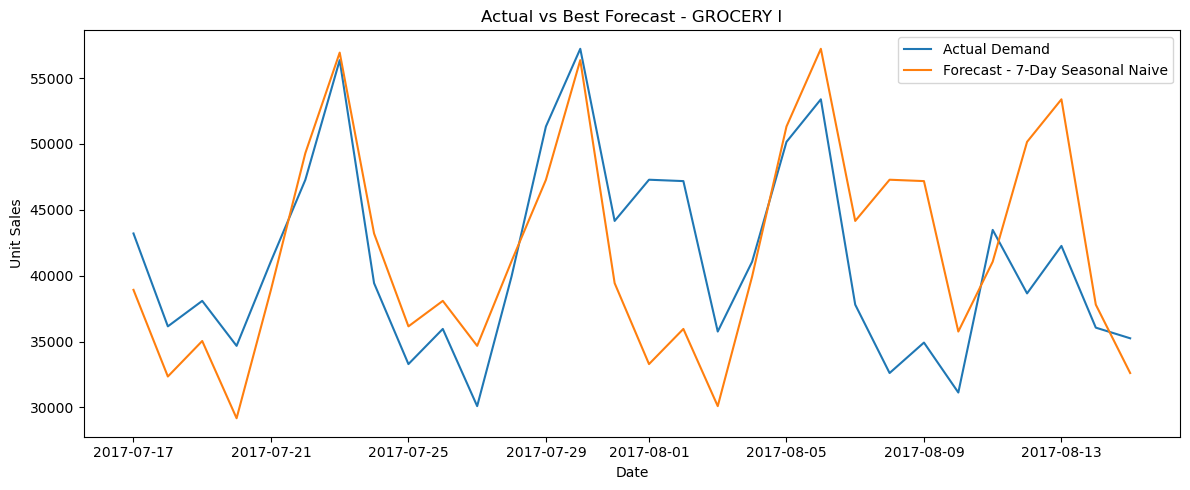

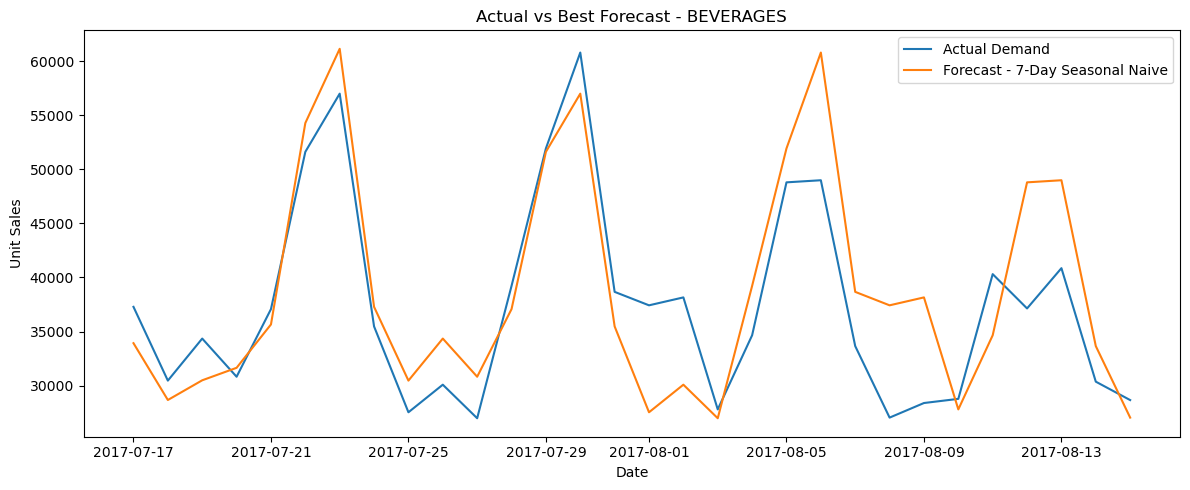

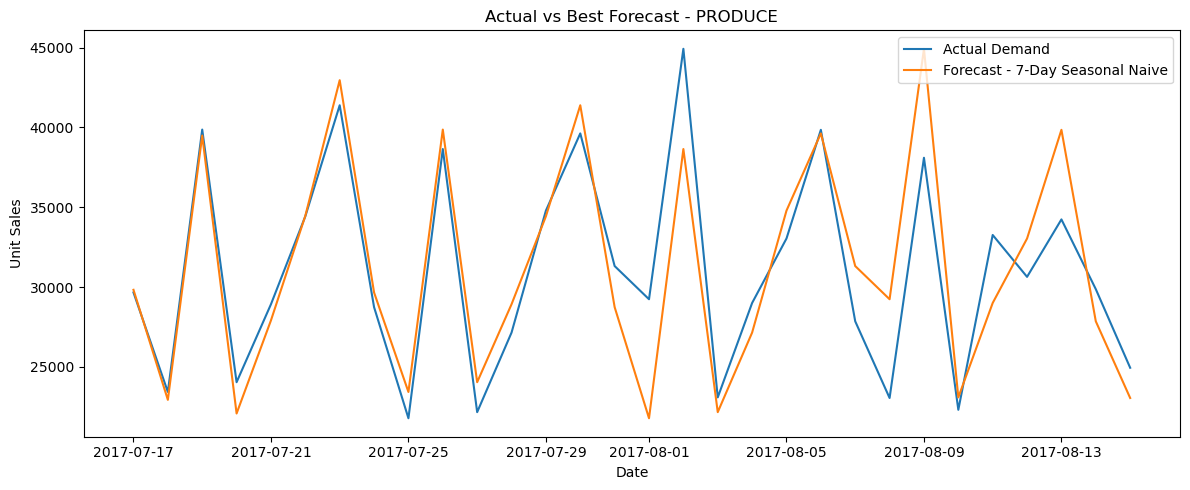

In [19]:
for family in top_3_families:
    
    best_model_name = best_models[
        best_models["family"] == family
    ]["model"].values[0]
    
    family_validation = all_validation[
        (all_validation["family"] == family) &
        (all_validation["model"] == best_model_name)
    ].copy()
    
    plt.figure(figsize=(12, 5))
    plt.plot(
        family_validation["date"],
        family_validation["actual"],
        label="Actual Demand"
    )
    plt.plot(
        family_validation["date"],
        family_validation["forecast"],
        label=f"Forecast - {best_model_name}"
    )
    plt.title(f"Actual vs Best Forecast - {family}")
    plt.xlabel("Date")
    plt.ylabel("Unit Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

Actual demand was plotted against the best forecast for each product family. This visual comparison helps show how closely the selected model follows recent demand patterns.

### Creating a function for future forecasts

In [20]:
def create_future_forecast(family_data, model_name, forecast_days=30):
    
    family_data = family_data.sort_values("date").copy()
    
    if model_name == "Naive Last Day":
        last_value = family_data["unit_sales"].iloc[-1]
        forecast_values = [last_value] * forecast_days
        
    elif model_name == "7-Day Moving Average":
        average_value = family_data["unit_sales"].tail(7).mean()
        forecast_values = [average_value] * forecast_days
        
    elif model_name == "14-Day Moving Average":
        average_value = family_data["unit_sales"].tail(14).mean()
        forecast_values = [average_value] * forecast_days
        
    elif model_name == "7-Day Seasonal Naive":
        last_7_days = family_data["unit_sales"].tail(7).tolist()
        forecast_values = [last_7_days[i % 7] for i in range(forecast_days)]
        
    elif model_name == "ARIMA(1,1,1)":
        arima_data = family_data.set_index("date").asfreq("D")
        
        model = ARIMA(
            arima_data["unit_sales"],
            order=(1, 1, 1)
        )
        
        model_fit = model.fit()
        forecast_values = model_fit.forecast(steps=forecast_days).values
        
    return forecast_values

A forecasting function was created to generate future demand based on the best model selected for each product family.

### Generating 30-day future forecast

In [21]:
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_forecasts = []

for family in top_3_families:
    
    family_data = daily_family_demand[
        daily_family_demand["family"] == family
    ].copy()
    
    best_model_name = best_models[
        best_models["family"] == family
    ]["model"].values[0]
    
    forecast_values = create_future_forecast(
        family_data,
        best_model_name,
        forecast_days=30
    )
    
    for date, forecast_value in zip(future_dates, forecast_values):
        future_forecasts.append({
            "date": date,
            "family": family,
            "best_model": best_model_name,
            "forecasted_demand": forecast_value
        })

future_forecast_df = pd.DataFrame(future_forecasts)

future_forecast_df.head()

,date,family,best_model,forecasted_demand
0,2017-08-16,GROCERY I,7-Day Seasonal Naive,34925.0
1,2017-08-17,GROCERY I,7-Day Seasonal Naive,31135.0
2,2017-08-18,GROCERY I,7-Day Seasonal Naive,43477.0
3,2017-08-19,GROCERY I,7-Day Seasonal Naive,38657.0
4,2017-08-20,GROCERY I,7-Day Seasonal Naive,42262.0


A 30-day future demand forecast was generated for each top product family using the best-performing model selected during validation.

### Removing negative forecast values

In [22]:
future_forecast_df["forecasted_demand"] = future_forecast_df["forecasted_demand"].clip(lower=0)

future_forecast_df.head()

,date,family,best_model,forecasted_demand
0,2017-08-16,GROCERY I,7-Day Seasonal Naive,34925.0
1,2017-08-17,GROCERY I,7-Day Seasonal Naive,31135.0
2,2017-08-18,GROCERY I,7-Day Seasonal Naive,43477.0
3,2017-08-19,GROCERY I,7-Day Seasonal Naive,38657.0
4,2017-08-20,GROCERY I,7-Day Seasonal Naive,42262.0


Forecasted demand values were clipped at zero because demand cannot be negative in a practical business context.

### Forecasting summary by family

In [23]:
forecast_summary = future_forecast_df.groupby("family")["forecasted_demand"].agg(
    total_30_day_forecast="sum",
    average_daily_forecast="mean",
    minimum_daily_forecast="min",
    maximum_daily_forecast="max"
).reset_index()

forecast_summary[[
    "total_30_day_forecast",
    "average_daily_forecast",
    "minimum_daily_forecast",
    "maximum_daily_forecast"
]] = forecast_summary[[
    "total_30_day_forecast",
    "average_daily_forecast",
    "minimum_daily_forecast",
    "maximum_daily_forecast"
]].round(2)

forecast_summary

,family,total_30_day_forecast,average_daily_forecast,minimum_daily_forecast,maximum_daily_forecast
0,BEVERAGES,995093.00,33169.77,28388.00,40858.00
1,GROCERY I,1113124.00,37104.13,31135.00,43477.00
2,PRODUCE,913832.11,30461.07,22313.77,38096.07


The 30-day forecast was summarized by product family to show expected total demand, average daily demand, and the forecasted demand range.

### Plotting 30-day forecast

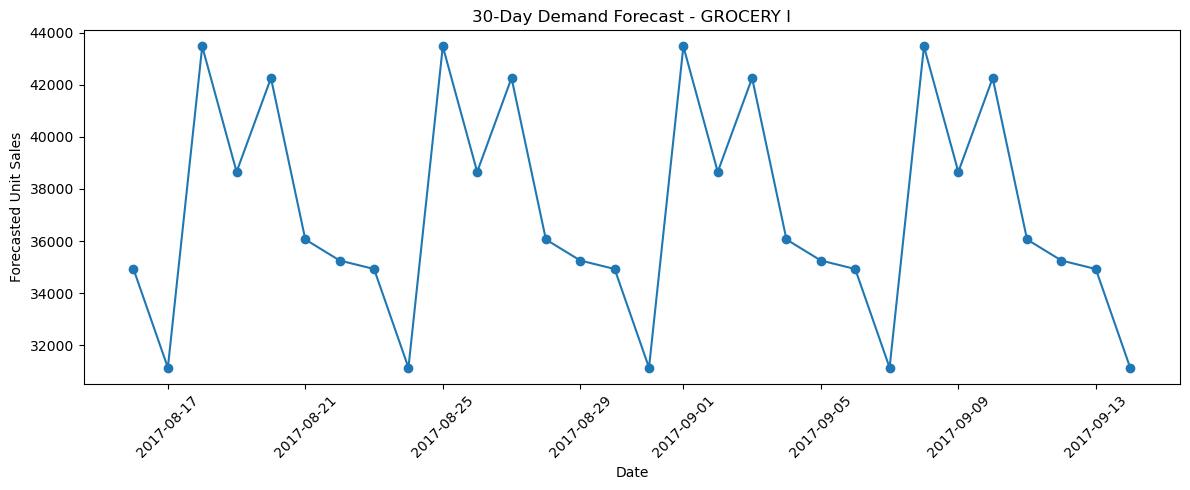

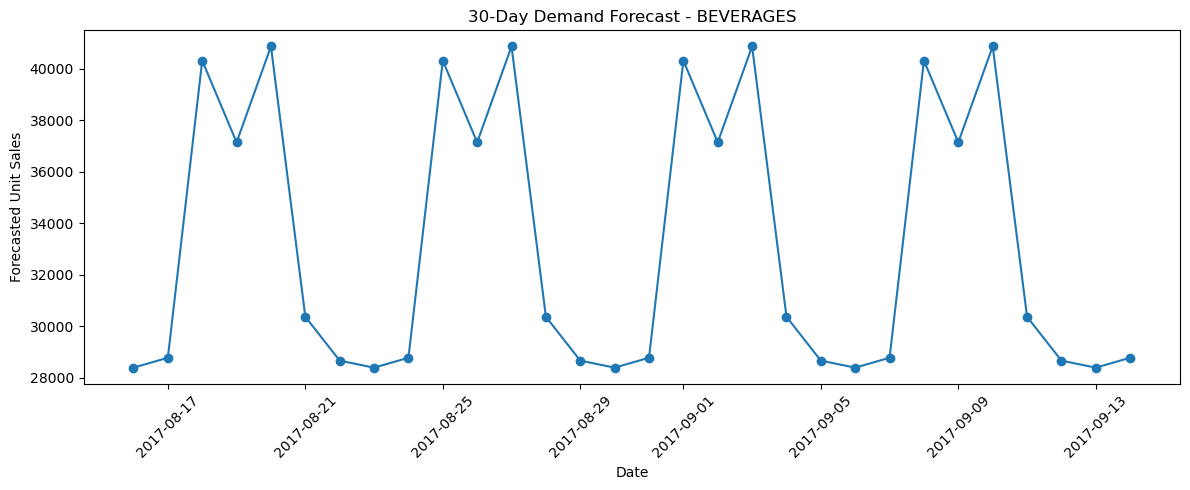

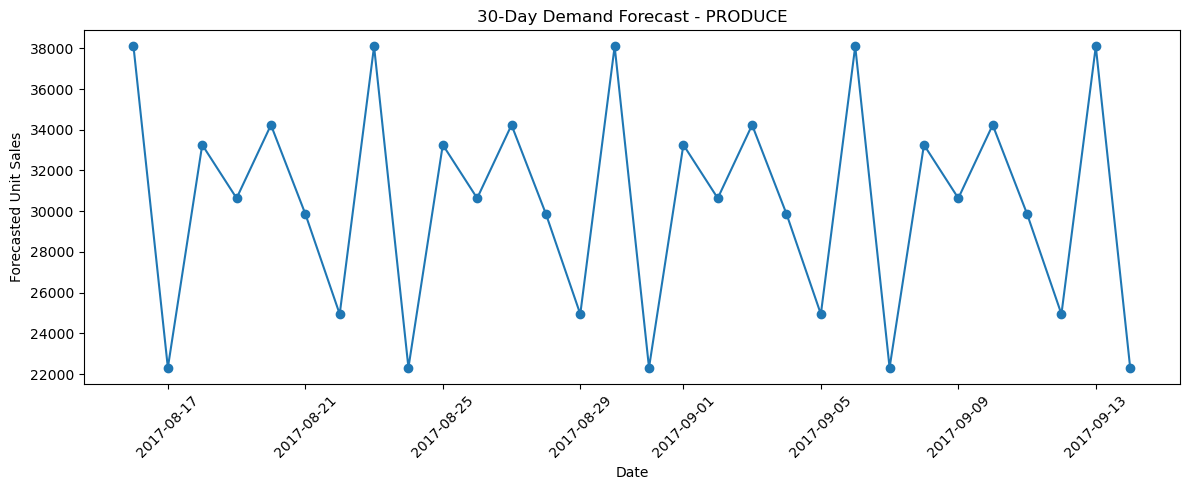

In [24]:
for family in top_3_families:
    
    family_forecast = future_forecast_df[
        future_forecast_df["family"] == family
    ].copy()
    
    plt.figure(figsize=(12, 5))
    plt.plot(
        family_forecast["date"],
        family_forecast["forecasted_demand"],
        marker="o"
    )
    plt.title(f"30-Day Demand Forecast - {family}")
    plt.xlabel("Date")
    plt.ylabel("Forecasted Unit Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The 30-day forecast was visualized for each product family to show expected short-term demand movement.

### Creating Power BI actual and forecast table

In [25]:
historical_actuals = daily_family_demand.copy()

historical_actuals = historical_actuals.rename(
    columns={"unit_sales": "demand"}
)

historical_actuals["data_type"] = "Actual"
historical_actuals["best_model"] = "Historical"

future_powerbi = future_forecast_df.rename(
    columns={"forecasted_demand": "demand"}
)

future_powerbi["data_type"] = "Forecast"

powerbi_forecast_data = pd.concat(
    [
        historical_actuals[["date", "family", "demand", "data_type", "best_model"]],
        future_powerbi[["date", "family", "demand", "data_type", "best_model"]]
    ],
    ignore_index=True
)

powerbi_forecast_data.head()

,date,family,demand,data_type,best_model
0,2016-01-01,GROCERY I,3247.000,Actual,Historical
1,2016-01-01,BEVERAGES,5104.000,Actual,Historical
2,2016-01-01,PRODUCE,2384.509,Actual,Historical
3,2016-01-02,GROCERY I,59749.726,Actual,Historical
4,2016-01-02,BEVERAGES,60006.000,Actual,Historical


A combined actual and forecast dataset was created for Power BI. This allows historical demand and future forecasted demand to be shown together in one visual.

### Saving forecasting outputs

In [26]:
all_model_results_rounded.to_csv(
    output_folder + r"\forecast_model_metrics.csv",
    index=False
)

best_models.to_csv(
    output_folder + r"\best_forecast_models.csv",
    index=False
)

all_validation.to_csv(
    output_folder + r"\forecast_validation_actual_vs_predicted.csv",
    index=False
)

future_forecast_df.to_csv(
    output_folder + r"\next_30_day_demand_forecast.csv",
    index=False
)

forecast_summary.to_csv(
    output_folder + r"\forecast_summary_by_family.csv",
    index=False
)

powerbi_forecast_data.to_csv(
    output_folder + r"\powerbi_actual_and_forecast_demand.csv",
    index=False
)

print("Forecasting outputs saved successfully.")

Forecasting outputs saved successfully.


Forecasting output files were saved for documentation, Power BI reporting, and the next inventory optimization stage.

### Final forecasting insights

## Forecasting Insights

1. The forecasting analysis focused on the top three product families: `GROCERY I`, `BEVERAGES`, and `PRODUCE`.

2. These families were selected because they contribute 75.85% of total demand within the selected project scope.

3. A 30-day test period was used to evaluate forecast accuracy.

4. Four baseline models were compared with an ARIMA(1,1,1) model.

5. The 7-Day Seasonal Naive model performed best for all three product families based on RMSE.

6. ARIMA(1,1,1) was tested as an advanced statistical model, but it did not outperform the best baseline model.

7. This result suggests that weekly demand patterns are important for the selected grocery categories.

8. The final 30-day forecast provides expected short-term demand for the highest-priority product families.

9. These forecast outputs will support inventory optimization by providing demand estimates before calculating replenishment recommendations.

## Business Interpretation

The forecast helps the business estimate short-term demand for its most important grocery categories. Since `GROCERY I`, `BEVERAGES`, and `PRODUCE` represent most of the selected demand, forecasting these categories can support better replenishment planning and inventory prioritization.

The fact that the 7-Day Seasonal Naive model outperformed ARIMA shows that simple, explainable models can be highly useful when demand follows a weekly pattern.

## Conclusion

This notebook developed and compared demand forecasting models for the top three product families in the grocery retail network.

The modelling approach started with simple baseline forecasts and then tested ARIMA as a more advanced statistical model. The best model for each product family was selected based on RMSE, ensuring that model selection was based on performance rather than assumption.

The next notebook will use the forecast results to support inventory optimization through ABC classification, safety stock calculation, reorder point estimation, and replenishment risk analysis.